# L20 · Reading AlphaFold's Confidence

*Companion notebook for Lecture 20 — Modern AI for Biology and Medicine (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Fetch a predicted structure and its confidence outputs from the AlphaFold Protein Structure Database (AlphaFold DB).
2. Plot per-residue **pLDDT** and the **PAE** matrix and say what each one does and does not tell you.
3. Relate low pLDDT to intrinsically disordered regions annotated in UniProt (p53, α-synuclein).
4. Compute a residue contact map from the predicted coordinates (Cβ–Cβ distance $d_{ij} < 8$ Å).

Notation (as on the slides): residues $i, j = 1,\dots,L$; $\mathbf x_i\in\mathbb R^3$ the Cα (or Cβ) position of
residue $i$; distance $d_{ij} = \|\mathbf x_i - \mathbf x_j\|$; $\mathrm{PAE}_{ij}$ = expected position error (Å) at
residue $j$ when the predicted and true structures are aligned on residue $i$.

We do **not** run AlphaFold here (it needs large sequence databases and a GPU). We read its published predictions,
the same files the lecture's figures were computed from.

In [1]:
import sys, pathlib, json, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from matplotlib.collections import LineCollection
from course_utils import seed_everything, plot_style, DATA, PALETTE

warnings.filterwarnings("ignore", category=UserWarning)
rng = seed_everything(0)   # nothing here is random; kept for the course convention
plot_style()
plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12})
T0 = time.time()

## 1. Dataset: AlphaFold DB predictions for three human proteins

**What is measured.** Nothing is measured directly: AlphaFold 2 *predicts* the 3D coordinates of every atom of a
protein chain from its amino-acid sequence (plus a multiple sequence alignment of its homologs). Alongside the
coordinates it predicts how much to trust them:

- **pLDDT** (0–100, one number per residue): predicted local distance difference test — does the local
  neighbourhood of residue $i$ look right? AlphaFold DB bands: > 90 very high, 70–90 confident, 50–70 low, < 50 very low.
- **PAE** ($L\times L$ matrix, Å): predicted aligned error — if we superimpose prediction and truth on residue $i$,
  how far off is residue $j$? It tells us whether the *relative placement* of two parts (e.g., two domains) is known.

**One sample = one protein chain** (the canonical UniProt sequence, entry `AF-<accession>-F1`).
**Input:** the sequence (length $L$). **Output:** coordinates $\mathbf x_i$, pLDDT$_i$, PAE$_{ij}$.

| UniProt | protein | why it is here |
|---|---|---|
| P69905 | hemoglobin α (142 aa) | compact all-helical globin: a well-folded reference |
| P04637 | p53 (393 aa) | folded DNA-binding and tetramerization domains separated by disordered regions |
| P37840 | α-synuclein (140 aa) | disordered in solution, helical when bound to membranes |

**Why it matters.** AlphaFold DB holds over 214 million predicted structures; biologists use them daily to design
experiments. Reading the confidence correctly decides which parts of a model you can use (e.g., for a binding
pocket or a distance) and which you must not.

**Sources and licenses.** AlphaFold DB (EMBL-EBI / Google DeepMind; Jumper et al., *Nature* 2021;
Varadi et al., *NAR* 2024), data under **CC BY 4.0**, fetched through the public API
`https://alphafold.ebi.ac.uk/api/prediction/<UniProt>`. Region annotations ("Disordered") from UniProtKB
(`rest.uniprot.org`, CC BY 4.0). All files (≈ 1 MB) are cached once in `applications/data/alphafold/`.

In [2]:
API = "https://alphafold.ebi.ac.uk/api/prediction/{}"
CACHE = DATA / "alphafold"
CACHE.mkdir(exist_ok=True)

PROTEINS = {"P69905": "hemoglobin α", "P04637": "p53", "P37840": "α-synuclein"}


def _get(url, path):
    """Download url to path once (cached); return the text."""
    if not path.exists():
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        path.write_bytes(r.content)
    return path.read_text()


def fetch(acc):
    """AlphaFold DB entry for the canonical UniProt sequence: metadata, pLDDT, PAE, PDB text."""
    entries = json.loads(_get(API.format(acc), CACHE / f"{acc}_api.json"))
    # proteins with isoforms return several entries (AF-P04637-2-F1, ...): take the canonical AF-<acc>-F1
    meta = [m for m in entries if m["modelEntityId"] == f"AF-{acc}-F1"][0]
    conf = json.loads(_get(meta["plddtDocUrl"], CACHE / f"{acc}_plddt.json"))
    pae = json.loads(_get(meta["paeDocUrl"], CACHE / f"{acc}_pae.json"))[0]
    pdb = _get(meta["pdbUrl"], CACHE / f"{acc}.pdb")
    return meta, np.array(conf["confidenceScore"], float), np.array(pae["predicted_aligned_error"], float), pdb


def uniprot_disordered(acc):
    """UniProt 'Disordered' region annotations as a list of (start, end), 1-based inclusive."""
    js = json.loads(_get(f"https://rest.uniprot.org/uniprotkb/{acc}.json?fields=ft_region",
                         CACHE / f"{acc}_uniprot_regions.json"))
    return [(f["location"]["start"]["value"], f["location"]["end"]["value"])
            for f in js.get("features", []) if f["type"] == "Region" and f["description"] == "Disordered"]


raw = {acc: fetch(acc) for acc in PROTEINS}
rows = []
for acc, (meta, plddt, pae, pdb) in raw.items():
    rows.append(dict(accession=acc, protein=PROTEINS[acc], entry=meta["modelEntityId"], L=len(plddt),
                     model_version=f"v{meta['latestVersion']}", tool=meta["toolUsed"],
                     created=meta["modelCreatedDate"][:10], PAE_shape=pae.shape))
meta_table = pd.DataFrame(rows).set_index("accession")
meta_table

,protein,entry,L,model_version,tool,created,PAE_shape
accession,,,,,,,
P69905,hemoglobin α,AF-P69905-F1,142,v6,AlphaFold Monomer v2.0 pipeline,2025-08-01,"(142, 142)"
P04637,p53,AF-P04637-F1,393,v6,AlphaFold Monomer v2.0 pipeline,2025-08-01,"(393, 393)"
P37840,α-synuclein,AF-P37840-F1,140,v6,AlphaFold Monomer v2.0 pipeline,2025-08-01,"(140, 140)"


The slide numbers were computed from **AlphaFold DB model v6** (models dated 2025-08-01, "AlphaFold Monomer v2.0
pipeline"). The next cell warns if the database has moved on; then the numbers below may differ slightly from the
slides (the conclusions should not).

In [3]:
versions = {m["latestVersion"] for m, *_ in raw.values()}
print("AlphaFold DB model version(s):", versions)
if versions != {6}:
    print("NOTE: the slides used model v6; numbers below may differ slightly.")

AlphaFold DB model version(s): {6}


## 2. Exploration: what is in the files?

The PDB file holds one line per atom. AlphaFold writes the residue's pLDDT into the **B-factor column** (where
experimental structures store atomic displacement), so the same number appears twice: in the confidence JSON and in
the coordinates file. Let us parse the Cα and Cβ atoms and check.

In [4]:
def parse_pdb(pdb_text):
    """Cα and Cβ (Cα for glycine) coordinates and the per-residue B-factor, in residue order."""
    ca, cb, bf = {}, {}, {}
    for line in pdb_text.splitlines():
        if line.startswith("ATOM"):
            name, resi = line[12:16].strip(), int(line[22:26])
            xyz = [float(line[30:38]), float(line[38:46]), float(line[46:54])]
            if name == "CA":
                ca[resi], bf[resi] = xyz, float(line[60:66])
            elif name == "CB":
                cb[resi] = xyz
    idx = sorted(ca)
    CA = np.array([ca[i] for i in idx])
    CB = np.array([cb.get(i, ca[i]) for i in idx])
    return CA, CB, np.array([bf[i] for i in idx])


def dist(X):
    """All pairwise Euclidean distances d_ij between the rows of X (L x 3)."""
    return np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(-1))


P = {}
for acc, (meta, plddt, pae, pdb) in raw.items():
    CA, CB, bfac = parse_pdb(pdb)
    P[acc] = dict(name=PROTEINS[acc], meta=meta, plddt=plddt, pae=pae, CA=CA, CB=CB, L=len(plddt), D=dist(CB))
    print(f"{PROTEINS[acc]:13s} L = {len(plddt):3d}  Cα atoms = {len(CA):3d}  "
          f"max |B-factor − pLDDT| = {np.abs(bfac - plddt).max():.3f}  "
          f"sequence starts {meta['sequence'][:12]}…")

hemoglobin α  L = 142  Cα atoms = 142  max |B-factor − pLDDT| = 0.000  sequence starts MVLSPADKTNVK…
p53           L = 393  Cα atoms = 393  max |B-factor − pLDDT| = 0.000  sequence starts MEEPQSDPSVEP…
α-synuclein   L = 140  Cα atoms = 140  max |B-factor − pLDDT| = 0.000  sequence starts MDVFMKGLSKAK…


PAE is not symmetric in general: max |PAE_ij − PAE_ji| for p53 = 23.0 Å


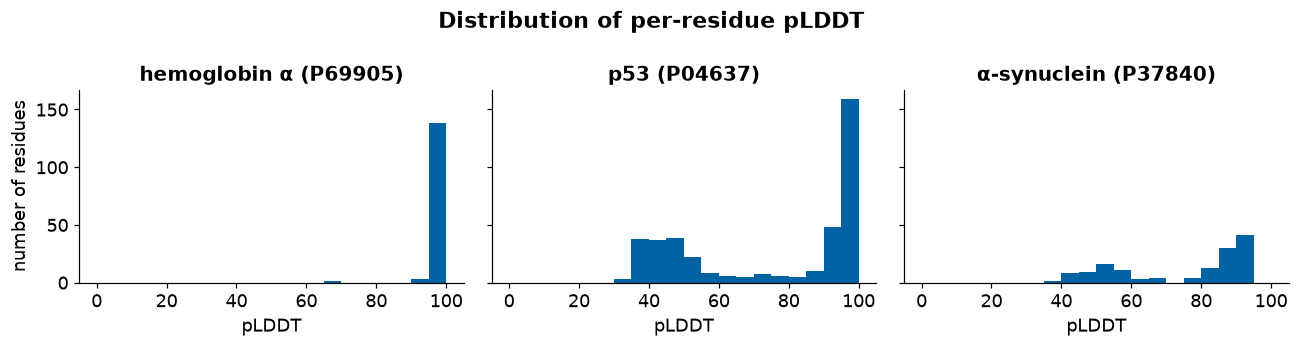

In [5]:
print("PAE is not symmetric in general: max |PAE_ij − PAE_ji| for p53 =",
      f"{np.abs(P['P04637']['pae'] - P['P04637']['pae'].T).max():.1f} Å")
fig, axs = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, (acc, p) in zip(axs, P.items()):
    ax.hist(p["plddt"], bins=np.arange(0, 101, 5), color=PALETTE[0])
    ax.set(title=f"{p['name']} ({acc})", xlabel="pLDDT")
axs[0].set_ylabel("number of residues")
fig.suptitle("Distribution of per-residue pLDDT", fontweight="bold")
fig.tight_layout()

## 3. Preprocessing: annotated regions

To relate confidence to biology we need region annotations. For **p53** we use UniProt's domain and "Disordered"
region features (the same lists as the lecture); for **α-synuclein**, the helices seen by NMR when the protein is
bound to detergent micelles (V3–V37 and K45–T92; Ulmer et al., *J. Biol. Chem.* 2005, PDB 1XQ8) and UniProt's
disordered C-terminal tail (100–140). Residue numbers are 1-based and inclusive; Python arrays are 0-based.

In [6]:
# UniProt P04637 features (retrieved 2026-09), as in slides_src/lectures/L20_modern_ai.py
P53_DOMAINS = [(1, 44, "TAD", "transactivation"), (102, 292, "DBD", "DNA binding"),
               (325, 356, "TET", "tetramerization")]
P53_DISORDERED = [(50, 96), (282, 325), (351, 393)]
ASYN_HELICES = [(3, 37), (45, 92)]
ASYN_DISORDERED = [(100, 140)]

# check the p53 list against the live UniProt record
print("UniProt 'Disordered' regions, p53:", uniprot_disordered("P04637"), "(lecture:", P53_DISORDERED, ")")
print("UniProt 'Disordered' regions, α-synuclein:", uniprot_disordered("P37840"))


def mask(L, regions):
    """Boolean vector of length L, True inside the 1-based inclusive regions."""
    m = np.zeros(L, bool)
    for a, b in regions:
        m[a - 1:b] = True
    return m

UniProt 'Disordered' regions, p53: [(50, 96), (282, 325), (351, 393)] (lecture: [(50, 96), (282, 325), (351, 393)] )
UniProt 'Disordered' regions, α-synuclein: [(100, 140)]


## 4. Model and training (what AlphaFold did, not repeated here)

AlphaFold 2 embeds the MSA and residue pairs, updates them with 48 Evoformer blocks (attention over MSA rows and
columns, triangle updates on pairs — L12), and turns the pair/single representations into 3D frames with the
structure module; the whole network is run 3 more times on its own output (recycling). It was trained on PDB
structures with the FAPE loss. The **confidence heads** are trained, too: the pLDDT head predicts the lDDT the
model would score against the true structure (binned, cross-entropy), and the PAE head predicts the aligned error
for every pair. So pLDDT and PAE are *predictions of the model's own error*, learned from data — they are not
measurements and not probabilities that a region is disordered.

## 5. Evaluation: confidence per protein and per region

In [7]:
BANDS = [(90, 100, "very high", "#0053D6"), (70, 90, "confident", "#65CBF3"),
         (50, 70, "low", "#FFDB13"), (0, 50, "very low", "#FF7D45")]   # AlphaFold DB colors

summary = pd.DataFrame({
    PROTEINS[acc]: {"L": p["L"], "mean pLDDT": p["plddt"].mean(), "% > 90": 100 * (p["plddt"] > 90).mean(),
                    "% < 50": 100 * (p["plddt"] < 50).mean(), "mean PAE (Å)": p["pae"].mean(),
                    "DB globalMetricValue": p["meta"]["globalMetricValue"]}
    for acc, p in P.items()}).T
summary.round(1)

,L,mean pLDDT,% > 90,% < 50,mean PAE (Å),DB globalMetricValue
hemoglobin α,142.0,98.1,99.3,0.0,2.1,98.1
p53,393.0,75.1,52.4,29.8,20.6,75.1
α-synuclein,140.0,75.2,28.6,12.9,23.9,75.2


In [8]:
hb, p53, asyn = P["P69905"], P["P04637"], P["P37840"]
print(f"hemoglobin α: mean pLDDT {hb['plddt'].mean():.1f}, {100 * (hb['plddt'] > 90).mean():.0f}% of residues > 90, "
      f"mean PAE {hb['pae'].mean():.1f} Å")

print(f"\np53: mean pLDDT {p53['plddt'].mean():.0f}; {100 * (p53['plddt'] < 50).mean():.0f}% of its {p53['L']} "
      f"residues < 50")
for a, b, tag, long in P53_DOMAINS:
    print(f"  {tag} {long:16s} ({a:3d}–{b:3d}): mean pLDDT {p53['plddt'][a - 1:b].mean():.0f}")
print(f"  UniProt 'disordered' regions  : mean pLDDT {p53['plddt'][mask(p53['L'], P53_DISORDERED)].mean():.0f}")
dbd, tet = slice(101, 292), slice(324, 356)          # residues 102–292 and 325–356
print(f"  PAE within DBD {p53['pae'][dbd, dbd].mean():.1f} Å, within TET {p53['pae'][tet, tet].mean():.1f} Å, "
      f"DBD→TET {p53['pae'][dbd, tet].mean():.0f} Å")

print(f"\nα-synuclein: mean pLDDT {asyn['plddt'].mean():.0f}; micelle helices (3–92) "
      f"{asyn['plddt'][mask(asyn['L'], ASYN_HELICES)].mean():.0f}; C-terminal tail (100–140) "
      f"{asyn['plddt'][mask(asyn['L'], ASYN_DISORDERED)].mean():.0f}")

hemoglobin α: mean pLDDT 98.1, 99% of residues > 90, mean PAE 2.1 Å

p53: mean pLDDT 75; 30% of its 393 residues < 50
  TAD transactivation  (  1– 44): mean pLDDT 49
  DBD DNA binding      (102–292): mean pLDDT 95
  TET tetramerization  (325–356): mean pLDDT 91
  UniProt 'disordered' regions  : mean pLDDT 53
  PAE within DBD 3.5 Å, within TET 2.9 Å, DBD→TET 20 Å

α-synuclein: mean pLDDT 75; micelle helices (3–92) 87; C-terminal tail (100–140) 51


**Contact map.** Two residues are *in contact* if their Cβ atoms (Cα for glycine) are closer than a cutoff,
$d_{ij} < 8$ Å. Pairs close in sequence are trivially close in space, so we count only $|i-j| \ge 6$. Contact maps are
what the co-evolution methods before AlphaFold tried to predict from the MSA (lecture Part 1), and a distogram
(binned $d_{ij}$) is one of AlphaFold's training targets.

In [9]:
CUTOFF = 8.0     # Å; try 6 or 12 (Try it yourself 2)
MIN_SEP = 6      # ignore |i - j| < MIN_SEP


def contacts(p, cutoff=CUTOFF, min_sep=MIN_SEP):
    L = p["L"]
    sep = np.abs(np.subtract.outer(np.arange(L), np.arange(L)))
    C = p["D"] < cutoff
    return C, int((C & (sep >= min_sep)).sum() // 2)


for acc, p in P.items():
    C, n_c = contacts(p)
    print(f"{p['name']:13s}: {n_c:4d} contacts with d_ij < {CUTOFF:g} Å and |i−j| ≥ {MIN_SEP} "
          f"({n_c / p['L']:.2f} per residue)")

hemoglobin α :  199 contacts with d_ij < 8 Å and |i−j| ≥ 6 (1.40 per residue)
p53          :  503 contacts with d_ij < 8 Å and |i−j| ≥ 6 (1.28 per residue)
α-synuclein  :    1 contacts with d_ij < 8 Å and |i−j| ≥ 6 (0.01 per residue)


Slide values (AlphaFold DB **v6**): hemoglobin α mean pLDDT 98.1, 99% of residues > 90, mean PAE 2.1 Å, 199 contacts;
p53 mean 75, DBD 95, TET 91, TAD 49, 30% of residues < 50, PAE 3.5 Å within the DBD vs 20 Å DBD–TET;
α-synuclein mean 75, helices 87, tail 51. The outputs above should match when the database is still at v6.

## 6. Visualization

### pLDDT along the sequence

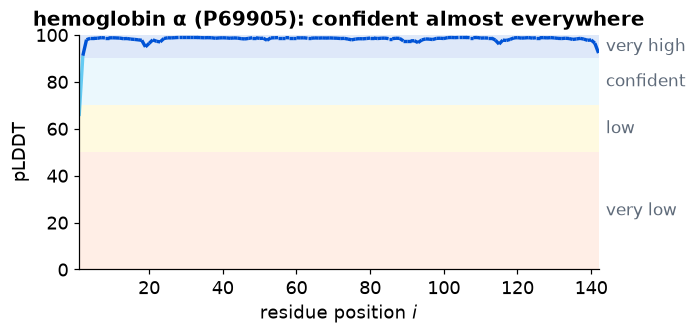

In [10]:
def band_color(v):
    for lo, hi, _, c in BANDS:
        if v >= lo:
            return c
    return BANDS[-1][3]


def plot_plddt(ax, p, title=None):
    """pLDDT along the sequence on the AlphaFold DB band background, each segment colored by its band."""
    v = p["plddt"]
    for lo, hi, lab, c in BANDS:
        ax.axhspan(lo, hi, color=c, alpha=0.13, lw=0)
    x = np.arange(1, len(v) + 1)
    pts = np.stack([x, v], 1)
    segs = np.stack([pts[:-1], pts[1:]], 1)
    ax.add_collection(LineCollection(segs, colors=[band_color((a + b) / 2) for a, b in zip(v[:-1], v[1:])],
                                     linewidths=2.2))
    ax.set(xlim=(1, len(v)), ylim=(0, 100), xlabel="residue position $i$", ylabel="pLDDT",
           title=title or f"{p['name']}, {p['L']} residues")


fig, ax = plt.subplots(figsize=(6.5, 3.2))
plot_plddt(ax, hb, "hemoglobin α (P69905): confident almost everywhere")
for lo, hi, lab, c in BANDS:
    ax.text(hb["L"] + 2, (lo + hi) / 2, lab, va="center", fontsize=11, color="#5F6B7A")
fig.tight_layout()

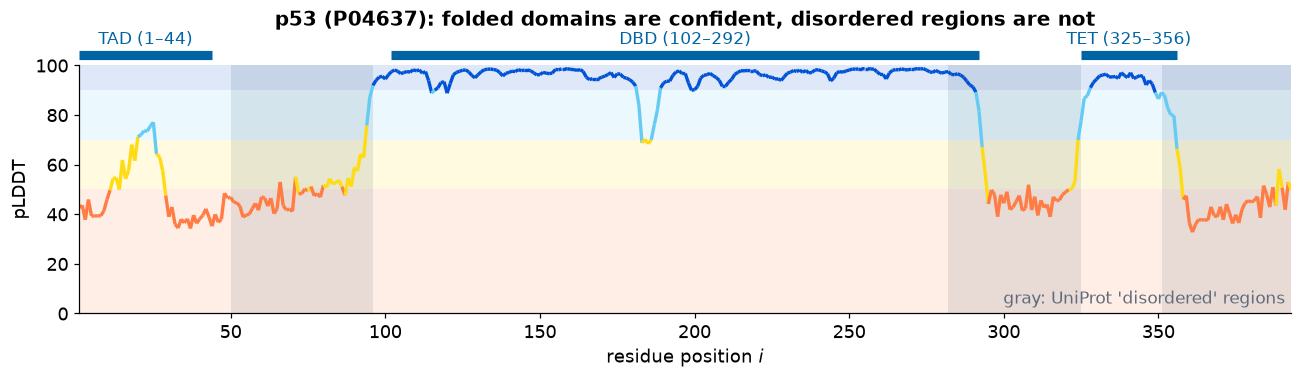

In [11]:
fig, ax = plt.subplots(figsize=(12, 3.6))
for a, b in P53_DISORDERED:
    ax.axvspan(a, b, color="#9AA5B1", alpha=0.25, lw=0)
plot_plddt(ax, p53, "p53 (P04637): folded domains are confident, disordered regions are not")
for a, b, tag, long in P53_DOMAINS:
    ax.plot([a, b], [104, 104], color=PALETTE[0], lw=6, solid_capstyle="butt", clip_on=False)
    ax.text((a + b) / 2, 107, f"{tag} ({a}–{b})", ha="center", va="bottom", fontsize=11, color=PALETTE[0],
            clip_on=False)
ax.text(0.995, 0.04, "gray: UniProt 'disordered' regions", transform=ax.transAxes, ha="right", fontsize=11,
        color="#5F6B7A")
ax.set_title(ax.get_title(), pad=26)
fig.tight_layout()

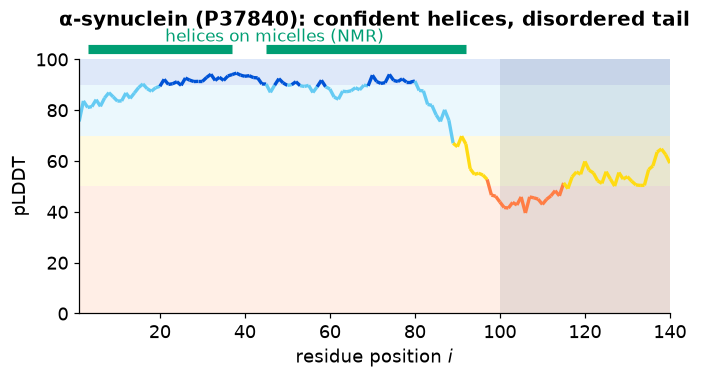

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for a, b in ASYN_DISORDERED:
    ax.axvspan(a, b, color="#9AA5B1", alpha=0.25, lw=0)
plot_plddt(ax, asyn, "α-synuclein (P37840): confident helices, disordered tail")
for a, b in ASYN_HELICES:
    ax.plot([a, b], [104, 104], color=PALETTE[2], lw=6, solid_capstyle="butt", clip_on=False)
ax.text(47, 107, "helices on micelles (NMR)", ha="center", fontsize=11, color=PALETTE[2], clip_on=False)
ax.set_title(ax.get_title(), pad=22)
fig.tight_layout()

### PAE: which parts are placed correctly *relative to each other*?

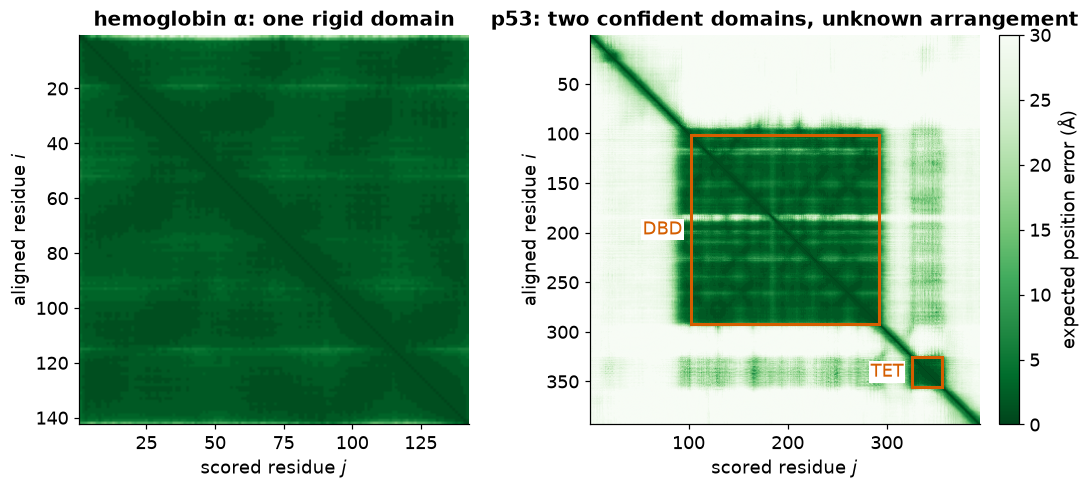

In [13]:
def plot_pae(ax, p, title=None):
    im = ax.imshow(p["pae"], cmap="Greens_r", vmin=0, vmax=30, extent=[0.5, p["L"] + 0.5, p["L"] + 0.5, 0.5])
    ax.set(xlabel="scored residue $j$", ylabel="aligned residue $i$", title=title or f"{p['name']}: PAE")
    return im


fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.6))
plot_pae(axs[0], hb, "hemoglobin α: one rigid domain")
im = plot_pae(axs[1], p53, "p53: two confident domains, unknown arrangement")
for a, b, tag, _ in P53_DOMAINS[1:]:
    axs[1].add_patch(plt.Rectangle((a, a), b - a, b - a, fill=False, ec=PALETTE[5], lw=2))
    axs[1].text(a - 8, (a + b) / 2, tag, color=PALETTE[5], fontsize=12, va="center", ha="right",
                bbox=dict(fc="white", ec="none", pad=1))
fig.colorbar(im, ax=axs, fraction=0.025, pad=0.02, label="expected position error (Å)");

### Distances and contacts from the coordinates

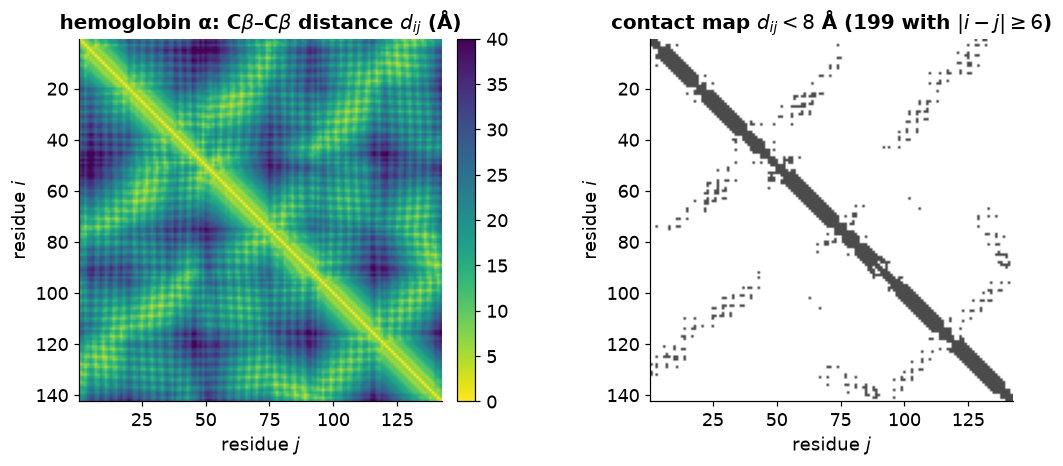

In [14]:
C, n_c = contacts(hb)
fig, axs = plt.subplots(1, 2, figsize=(11, 4.4))
im = axs[0].imshow(hb["D"], cmap="viridis_r", vmin=0, vmax=40, extent=[0.5, hb["L"] + 0.5, hb["L"] + 0.5, 0.5])
axs[0].set_title(r"hemoglobin α: C$\beta$–C$\beta$ distance $d_{ij}$ (Å)")
fig.colorbar(im, ax=axs[0], fraction=0.046, pad=0.03)
axs[1].imshow(C, cmap="Greys", vmin=0, vmax=1.3, extent=[0.5, hb["L"] + 0.5, hb["L"] + 0.5, 0.5])
axs[1].set_title(rf"contact map $d_{{ij}} < {CUTOFF:g}$ Å ({n_c} with $|i-j|\geq {MIN_SEP}$)")
for ax in axs:
    ax.set(xlabel="residue $j$", ylabel="residue $i$")
fig.tight_layout()

Thick bands along the diagonal are helices ($i, i\pm3, i\pm4$ are close); off-diagonal patches are helices packed
against each other — the globin fold.

### The 3D model, colored by pLDDT
A Cα trace of p53 viewed along its principal axes (our own rendering of the AlphaFold DB model). The blue parts are
the folded domains; the orange "spaghetti" are the disordered regions — their coordinates are placeholders, not
a structure.

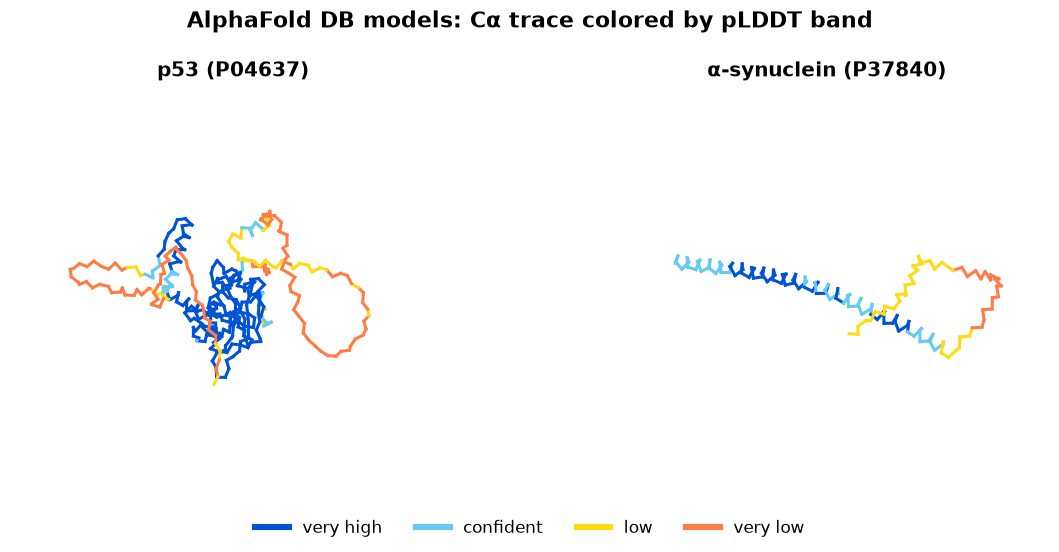

In [15]:
def plot_trace(p, ax):
    X = p["CA"] - p["CA"].mean(0)
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    Y = X @ Vt.T
    v = p["plddt"]
    for k in range(len(Y) - 1):
        ax.plot(Y[k:k + 2, 0], Y[k:k + 2, 1], Y[k:k + 2, 2], color=band_color((v[k] + v[k + 1]) / 2), lw=2)
    ax.view_init(elev=18, azim=-60)
    ax.set_box_aspect(np.ptp(Y, 0))
    ax.set_axis_off()


fig = plt.figure(figsize=(11, 5))
for k, acc in enumerate(["P04637", "P37840"]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    plot_trace(P[acc], ax)
    ax.set_title(f"{P[acc]['name']} ({acc})")
fig.suptitle("AlphaFold DB models: Cα trace colored by pLDDT band", fontweight="bold")
fig.legend(handles=[plt.Line2D([], [], color=c, lw=4, label=f"{lab}") for lo, hi, lab, c in BANDS],
           loc="lower center", ncol=4, fontsize=11)
fig.tight_layout()

## 7. Biological interpretation

- **Hemoglobin α** is a compact globin: pLDDT > 90 nearly everywhere and PAE ≈ 2 Å for every pair. Both local
  geometry and the global arrangement can be trusted. (But the functional unit is an α₂β₂ tetramer with four hemes;
  the DB model is a single apo chain.)
- **p53** is a textbook mix: the DNA-binding domain (where most cancer mutations lie) and the tetramerization
  domain are each predicted confidently, but the PAE between them is ~20 Å — *each domain is right, their
  arrangement is unknown*. Never measure an inter-domain distance in such a model. The UniProt "disordered" regions
  have very low pLDDT: low confidence here means *no single structure*, not a bad model.
- **α-synuclein** is disordered in solution, yet AlphaFold predicts long helices for residues 3–92 with pLDDT ≈ 87 —
  the conformation it adopts **on membranes**. AlphaFold predicts a structure seen in *some* context, not the
  ensemble in a given condition. High pLDDT does not prove a region is folded in the cell; low pLDDT does not prove
  it never orders (many disordered regions fold on binding a partner — note the bump near p53 residues 15–25).
- pLDDT and PAE are the model's estimates of its own error; shallow MSAs (few homologs) also lower confidence.
  None of this is a clinical statement about a protein or a variant.

Runtime of this notebook:

In [16]:
print(f"total runtime {time.time() - T0:.1f} s")

total runtime 6.2 s


## 8. Try it yourself

1. **Your favorite protein: which domains does PAE reveal?** Set `FAVORITE` in the cell below to any UniProt
   accession and re-run it (calmodulin `P0DP23` is a good start: two EF-hand lobes on a flexible linker). Where are
   the dark squares on the PAE diagonal? Do they match the domains in its UniProt entry?
2. **Contact cutoff 6 Å or 12 Å instead of 8 Å.** Change `CUTOFF` in Section 5 (or call
   `contacts(hb, cutoff=6)`). How does the number of contacts per residue scale with the cutoff? Which structural
   elements appear or disappear in the contact map?
3. **pLDDT as a disorder predictor: ROC curve vs UniProt.** Label residues inside UniProt "Disordered" regions
   (`uniprot_disordered(acc)` + `mask`) as positives, use $100 - \mathrm{pLDDT}$ as the score, and plot the ROC
   curve with `sklearn.metrics.roc_curve` for p53 and α-synuclein. What AUC do you get? Which false positives
   remain, and are they really errors (think of α-synuclein's helices)?
4. Compute the mean pLDDT of the residues that make **long-range** contacts ($|i-j| \geq 24$) vs the rest for p53.
   Why do disordered regions have almost none?
5. *(CS284A)* Find domains automatically: turn PAE into an affinity $A_{ij} = \exp(-\tfrac12(\mathrm{PAE}_{ij} +
   \mathrm{PAE}_{ji})/5)$ and cluster residues with `sklearn.cluster.SpectralClustering(affinity="precomputed")`
   (L14). Do you recover p53's DBD and tetramerization domain? How do you handle the disordered residues?

AF-P0DP23-F1 (Calmodulin-1), model v6: L = 149, mean pLDDT 85.2, mean PAE 13.3 Å


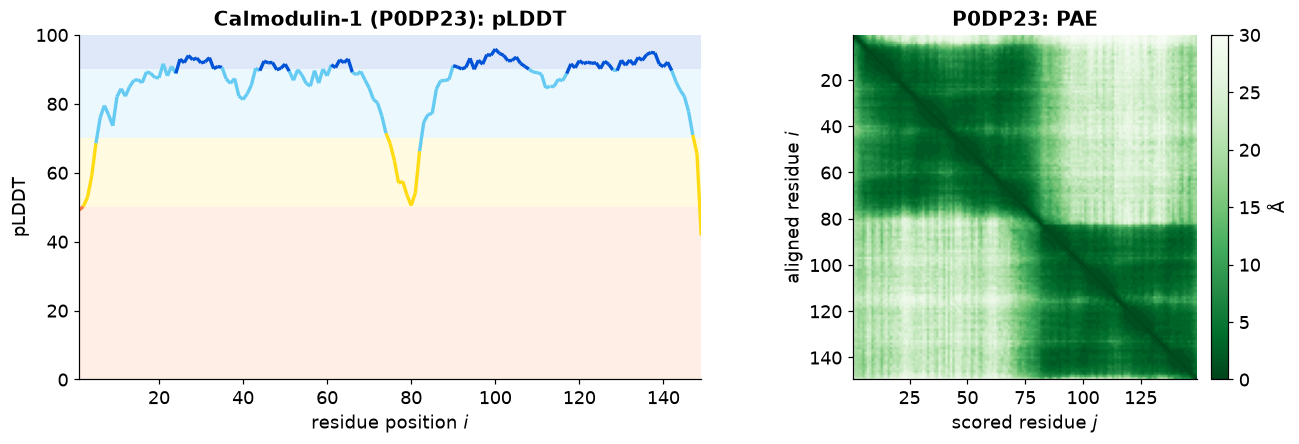

In [17]:
FAVORITE = "P0DP23"   # calmodulin-1; put any UniProt accession here
meta_f, plddt_f, pae_f, pdb_f = fetch(FAVORITE)
fav = dict(name=meta_f.get("uniprotDescription", FAVORITE), plddt=plddt_f, pae=pae_f, L=len(plddt_f))
print(f"{meta_f['modelEntityId']} ({meta_f['uniprotDescription']}), model v{meta_f['latestVersion']}: "
      f"L = {fav['L']}, mean pLDDT {plddt_f.mean():.1f}, mean PAE {pae_f.mean():.1f} Å")
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw=dict(width_ratios=[1.4, 1]))
plot_plddt(axs[0], fav, f"{fav['name']} ({FAVORITE}): pLDDT")
im = plot_pae(axs[1], fav, f"{FAVORITE}: PAE")
fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.03, label="Å")
fig.tight_layout()